<a href="https://colab.research.google.com/github/ollihansen90/MatheSH_Pseudozufall/blob/main/Monte_Carlo_Beispiele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def zufalls_generator(a, b, m):
    def gen(x):
        while True:
            x = (a*x+b)%m
            yield x
    return gen

def zufalls_generator_fib(a_folge, b, m):
    def gen(startwerte):
        werte = list(startwerte)

        while True:
            x = (sum(ai * xi for ai, xi in zip(a_folge, reversed(werte))) + b) % m

            werte.append(x)
            werte.pop(0)

            yield x

    return gen

def zufalls_generator2(seed=0.4):
    x = seed
    while True:
        yield x
        x = 4*x*(1-x)

def list_generator(n, seed=0.4):
    gen = zufalls_generator2(seed)
    liste = []
    for i in range(n):
        liste.append(next(gen))
    return liste

def create_random_list(liste, lens=3):
    N = int(len(liste)/lens)*lens
    out = [sum([liste[i+k]*10**(-k-1) for k in range(lens)]) for i in range(0, N-lens)]
    return out

test = [1,1,1,2,3,4,4,1,1,1,1,3]
print(create_random_list(test))

generator_funktion = zufalls_generator_fib(
    a_folge=[3,2,2,1,1],
    b=5,
    m=13
)


generator = generator_funktion([6,2,2,6,5])

for _ in range(10):
    print(next(generator))

[0.111, 0.112, 0.12300000000000001, 0.234, 0.34400000000000003, 0.441, 0.41100000000000003, 0.111, 0.111]
5
7
2
7
2
2
12
6
8
4


In [ ]:
raw = """
Heute
Sie 28.05.2026 17:02 • 2375886768940329282646576867546473882716254565748894399020181891913747577564563552
Neue Nachrichten
Kira Mailin Ley 28.05.2026 17:02 • 62914081237461293421348620847160837416023874160234601823740176107630215
Sie 28.05.2026 17:02 • 98720981495871486043850275097164509364591457615914509817209561354961
Sie 28.05.2026 17:04 • 231648178416864513
64584535168413451684335135418468420216820001368468423135434879843121
"""


Heute
2375886768940329282646576867546473882716254565748894399020181891913747577564563552
Neue Nachrichten
62914081237461293421348620847160837416023874160234601823740176107630215
98720981495871486043850275097164509364591457615914509817209561354961
231648178416864513
64584535168413451684335135418468420216820001368468423135434879843121

2 3 7 5 8 8 6 7 6 8 9 4 0 3 2 9 2 8 2 6 4 6 5 7 6 8 6 7 5 4 6 4 7 3 8 8 2 7 1 6 2 5 4 5 6 5 7 4 8 8 9 4 3 9 9 0 2 0 1 8 1 8 9 1 9 1 3 7 4 7 5 7 7 5 6 4 5 6 3 5 5 2 6 2 9 1 4 0 8 1 2 3 7 4 6 1 2 9 3 4 2 1 3 4 8 6 2 0 8 4 7 1 6 0 8 3 7 4 1 6 0 2 3 8 7 4 1 6 0 2 3 4 6 0 1 8 2 3 7 4 0 1 7 6 1 0 7 6 3 0 2 1 5 9 8 7 2 0 9 8 1 4 9 5 8 7 1 4 8 6 0 4 3 8 5 0 2 7 5 0 9 7 1 6 4 5 0 9 3 6 4 5 9 1 4 5 7 6 1 5 9 1 4 5 0 9 8 1 7 2 0 9 5 6 1 3 5 4 9 6 1 2 3 1 6 4 8 1 7 8 4 1 6 8 6 4 5 1 3 6 4 5 8 4 5 3 5 1 6 8 4 1 3 4 5 1 6 8 4 3 3 5 1 3 5 4 1 8 4 6 8 4 2 0 2 1 6 8 2 0 0 0 1 3 6 8 4 6 8 4 2 3 1 3 5 4 3 4 8 7 9 8 4 3 1 2 1
307
{'2': 26, '3': 29, '7': 26, '5': 30, '8': 36,

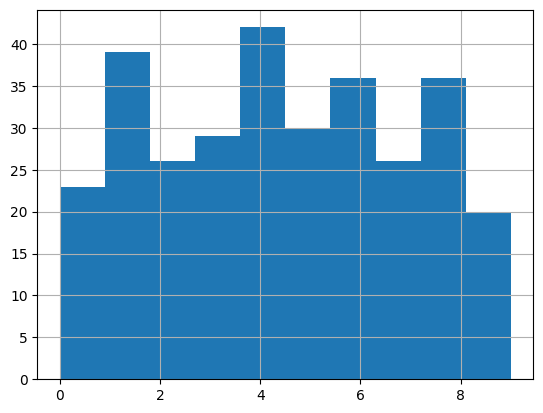

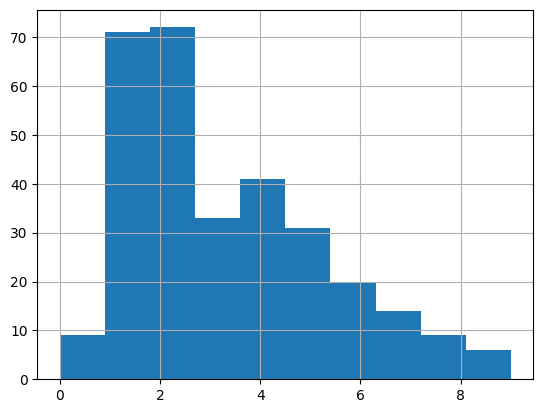

In [ ]:
def nur_zahlen(string):
    zahlenliste = [str(i) for i in range(10)]
    for z in set(list(string)):
        if z not in zahlenliste:
            return False
    return True

lliste = raw.split("\n")
liste = []
for l in lliste:
    if "•" in l :
        l = l.split("•")[-1]
    l = l.strip()
    nz = nur_zahlen(l)
    print(l)
    if not nz:
        continue
    liste.append(l)


rawlonglist = ""
for i in liste:
    rawlonglist = rawlonglist+i
print(*rawlonglist)
ziffern = [str(i) for i in range(10)]
longlist = []
for i in range(len(rawlonglist)):
    if rawlonglist[i] in ziffern:
        longlist.append(rawlonglist[i])
for eintrag in longlist:
    if eintrag not in [str(i) for i in range(10)]:
        print(eintrag)
print(len(longlist))

data_list = np.array([*longlist], dtype=int)
data_dict = dict()
for i in longlist:
    if i in data_dict.keys():
        data_dict[i] += 1
    else:
        data_dict[i] = 1
print(data_dict)

plt.figure()
plt.hist(data_list)
plt.grid()
plt.show()

plt.figure()
plt.hist(np.abs(data_list[:-1]-data_list[1:]))
plt.grid()
plt.show()

In [ ]:
eingabe = ""
for _ in range(10000):
    eingabe += str(np.random.randint(0,10))
print(eingabe)

1831934573163409485875922874227500827473523194510906648037752213521286171898683188095083627727574503539607533394613232464025100219665898010193496567278257252524756660581370088951380029932415504200201992328941013582102839220803246092724077970095596347400592189556853283572005633384231984761043474557843857304880930045326735582266191353679402122346253401656737921623090626113215124060939290459446374767376318824128403455443611462131229292292832937002206241827827317627117662022606463863740935869053456280398514525051699189595049031025318264370135230674232045354389551667348327207894684600567385776381989443235162745963913475687166424640332754070997656741490411528977748565199999748724035253426483170874576516454101883809825913648427741087427809075935672536020426665668524415283369813815049511168198392943963217859459175089376157512885289616685708278495139303093511058204620102887475516354811653648318245801567247873400711852228626601853133521121368219114114488342853672875925893006424889912949661392780

In [ ]:
N = 200_000
data_list = (10*np.random.rand(N)).astype(int)
data = 2*np.random.rand(2,N)-1
N = len(data_list)
data = 2*np.stack((create_random_list(data_list[:int(N/2)]), create_random_list(data_list[int(N/2):])), axis=0)-1
labels = (data[0]**2+data[1]**2)<1
N = len(labels)
print(4*sum(labels)/N)
labels_cumsum = 4*np.cumsum(labels)/(np.arange(N)+1)
labels_diff = np.abs(labels_cumsum-np.pi)

plt.figure(figsize=[16,5])
plt.subplot(1,2,1)
plt.scatter(data[0, labels==1], data[1, labels==1], marker=".")
plt.scatter(data[0, labels==0], data[1, labels==0], marker=".")
plt.axis("equal")
plt.subplot(1,2,2)
plt.plot(labels_cumsum)
plt.plot([0,N], [np.pi,np.pi])
plt.grid()
plt.show()

plt.figure()
plt.plot(np.log(labels_diff))
plt.show()

print(np.argmin(labels_diff),labels_cumsum[np.argmin(labels_diff)])

In [ ]:
N = 10_000
n_wuerfe = 2_000
data = np.random.randint(1,7, (n_wuerfe,N)).sum(axis=0)
data_dict = {}
for d in data:
    if d in data_dict.keys():
        data_dict[d] += 1
    else:
        data_dict[d] = 1

plt.figure()
plt.bar(data_dict.keys(), data_dict.values())
plt.show()

In [ ]:
image = np.zeros((160,160))
obj1 = np.outer(np.linspace(-1,1, num=80), np.linspace(-1,1, num=80))
obj1 = obj1**2<0.01
image[0:80,0:80] = obj1
obj2 = np.outer(np.sin(10*np.linspace(-1,1, num=80))>0, np.ones(80))
image[0:80,80:] = obj2
image[80:,0:80] = obj2.T
obj3 = obj2+obj2.T
image[80:,80:] = np.abs(obj3-1)

plt.figure()
plt.imshow(image)
plt.show()

print(image.sum())
print(40_000-image.sum())

In [ ]:
n_models = 50
n_changes = 10
n_epochs = 4_000
patch_sizes = iter([10, 8, 6, 4, 3, 2, 1])
img_list = [np.random.randint(0,2,(160,160)) for i in range(n_models)]
bestlosses = np.zeros(n_epochs)
best_idx = 0

switchlist = [0, int(n_epochs/100), int(n_epochs/40), int(n_epochs/20), int(n_epochs/13.333), int(n_epochs/2.5), int(n_epochs*9/10)]
print(switchlist)
for epoch in range(n_epochs):
    if epoch in switchlist:
        patch_size = next(patch_sizes)
    losses = [np.sum((img.flatten()-image.flatten())**2) for img in img_list]
    if epoch%100==0:
        print(epoch, best_idx, np.min(losses), patch_size)
        plt.figure(figsize=[15,5])
        for i in range(5):
            plt.subplot(1,5,i+1)
            plt.imshow(img_list[i])
            plt.title(losses[i])
        plt.show()
    best_idx = np.argmin(losses)
    bestlosses[epoch] = np.min(losses)
    if epoch%20==0:
        print(epoch, best_idx, np.min(losses), patch_size)
    img_list[0] = img_list[best_idx]

    for i in range(1,n_models):
        img = img_list[0].copy()
        for _ in range(n_changes):
            idx = np.random.randint(0,160, (2,))
            img[idx[0]:idx[0]+patch_size+1, idx[1]:idx[1]+patch_size+1] = np.random.randint(0,2)
            #print(img[idx[0]:idx[0]+2, idx[1]:idx[1]+2].shape)
        img_list[i] = img

plt.figure()
plt.plot(bestlosses)
plt.show()

plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
plt.imshow(image)
plt.subplot(1,2,2)
plt.imshow(img_list[best_idx])
plt.show()

In [ ]:
print(10**100000000)

In [ ]:
import random
import matplotlib.pyplot as plt

N = 2*3*4*5*6*7*50
print(N)
randlist = [random.randint(1,6) for i in range(N)]
randdict = dict()
for zahl in randlist:
    if zahl in randdict.keys():
        randdict[zahl] += 1
    else:
        randdict[zahl] = 0
print(randdict)

n = 2
randlist2 = [sum([randlist[i+k]*8**(i>0) for i in range(n)])%10 for k in range(0,N, n)]
print(randlist2)

randdict2 = dict()
for zahl in randlist2:
    if zahl in randdict2.keys():
        randdict2[zahl] += 1
    else:
        randdict2[zahl] = 0
print(randdict2)

plt.figure()
plt.bar(randdict.keys(), randdict.values())
plt.show()
plt.figure()
plt.bar(randdict2.keys(), randdict2.values())
plt.show()


In [ ]:
# Monte-Carlo-Analyse der Treffer bei Monopoly
import random

# init Felder
n_Felder = 40
Monopoly = True
if Monopoly:
    n_Felder = 40

Felder = {}
for i in range(n_Felder):
    Felder[i] = 0
# Namen der Felder
Felder_echt = ["Start", "Badstr", "GS1", "Turmstr", "Einkommensteuer", "Südbahnhof", "Chausseestr", "EF1", "Elisenstr", "Poststr",
               "Gefängnis", "Seestr", "EWerk", "Hafenstr", "Neue Str", "Westbahnhof", "Münchener Str", "GS2", "Wiener Str", "Berliner Str", "FreiParken",
               "Theaterstr", "EF2", "Museumsstr", "Opernplatz", "Nordbahnhof", "Lessingstr", "Schillerstr", "WWerk", "Goethestr", "Knast",
               "Rathausplatz", "Hauptstr", "GS3", "Bahnhofsstr", "Hauptbahnhof", "EF3", "Parkstr", "Zusatzsteuer", "Schlossallee"]

# Simuliere Züge
n_Zuege = 30
n_Spiele = 100_000
startfeld = 0

for i in range(n_Spiele):
    feld = startfeld % n_Felder
    for j in range(n_Zuege):
        schritt = random.randint(1,6) + random.randint(1,6)
        feld = (feld+schritt) % n_Felder
        Felder[feld]+=1
        if feld == 30 & Monopoly:
            feld = 10

# Sortiere nach Anzahl der Treffer
Felder_sortiert = sorted(Felder, key=Felder.__getitem__, reverse=True)

if Monopoly:
    for i in range(n_Felder):
        print(str(Felder_echt[Felder_sortiert[i]]) + ": " + str(Felder[Felder_sortiert[i]]))
else:
    for i in range(n_Felder):
        print(str(Felder_sortiert[i]) + ": " + str(Felder[Felder_sortiert[i]]))


In [ ]:
#a, b, m = 6_364_136_223_846_793_005, 2_531_011, 2**64
a, b, m = 2, 3 ,13
x = 0
gen = zufalls_generator(a, b, m)
gen = zufalls_generator2()
liste = []
"""for i in range(13):
    x = next(gen(x))
    liste.append(x/m)"""

liste = list_generator(10_000)

unifizer = lambda x: 2/np.pi*np.arcsin(np.sqrt(x))

liste = np.array(liste)
liste_n = unifizer(liste)
N = 10

data_dict = dict()
for i in range(N):
    idx1 = i/N
    idx2 = (i+1)/N
    d1 = liste_n<idx1
    d2 = liste_n>=idx2
    d3 = 1-(1*d1+1*d2)
    data_dict[i] = sum(d3)

print(data_dict)

plt.figure()
plt.bar(data_dict.keys(), data_dict.values())
plt.show()

plt.figure()
plt.plot(liste, ".")
plt.show()

params = [i/10+1e-7 for i in range(1,10)]
plt.figure(figsize=[20,5])
for param in params:
    liste = np.array(list_generator(10000, seed=param))
    liste = unifizer(liste)-0.5
    plt.plot(np.cumsum(liste))
#plt.legend(params)
plt.grid()
plt.show()